In [8]:
"""
Final cleaning pass on AllRoles_clean.csv, producing the dataset that's
actually ready to send to the NIOCCS API.

Output: one row per unique historical opportunity, restricted to the 4
core Career Launch/Spring Forward hubs, where both the role name and role
description have real (non-placeholder, non-blank) content. Short/generic
content is fine and is NOT filtered out here - only rows with nothing
usable are dropped.

FILTERS APPLIED (in order, each one printed so nothing disappears quietly)
---------------------------------------------------------------------------
1. Hub Normalized must be one of the 4 core hubs:
   Healthcare, STEM and Green, Community and Social Services,
   Marketing and Communications.
   (Government and Public Service is dropped here - it only ever existed
   in the 2022 cohort and isn't one of the 4 hubs going forward. Cultural
   Corps/I2E rows were already out of scope per the diagnostic pass.)
2. Opportunity Name (role name) must be non-blank.
3. Opportunity Description (role description) must be non-blank.
4. Opportunity Name must not be an unfilled placeholder/template stub
   (e.g. "Enter Your Job Title Here") - these have text, but it isn't
   real content, so they don't satisfy "at least something."
5. Duplicate Opportunity Ids are dropped, keeping the first occurrence
   (there weren't any in the raw file, but this makes the "one row per
   unique historical opportunity" guarantee explicit rather than assumed).

Everything that survives keeps its own text as-is, however short or
generic - per direction, that's fine.
"""

import pandas as pd
import re

IN_PATH = "../../data/AllRoles_clean.csv"
OUT_PATH = "../../data/AllRoles_nioccs_ready.csv"

CORE_HUBS = {
    "Healthcare",
    "STEM and Green",
    "Community and Social Services",
    "Marketing and Communications",
}

PLACEHOLDER_TITLE_RE = re.compile(
    r"enter your job title here|insert title of position here|"
    r"organization name.*job position|insert name of org",
    re.I,
)


def is_placeholder_title(title):
    if pd.isna(title):
        return False
    return bool(PLACEHOLDER_TITLE_RE.search(str(title)))


def main():
    df = pd.read_csv(IN_PATH, encoding="utf-8-sig", low_memory=False)
    n_start = len(df)
    print(f"Starting rows: {n_start}")

    # 1. Restrict to the 4 core hubs
    df = df[df["Hub Normalized"].isin(CORE_HUBS)]
    print(f"After restricting to the 4 core hubs: {len(df)} (-{n_start - len(df)})")
    n = len(df)

    # 2 & 3. Both title and description must be non-blank
    df = df[df["Opportunity Name"].notna() & (df["Opportunity Name"].str.strip() != "")]
    df = df[df["Opportunity Description"].notna() & (df["Opportunity Description"].str.strip() != "")]
    print(f"After requiring non-blank title AND description: {len(df)} (-{n - len(df)})")
    n = len(df)

    # 4. Drop unfilled placeholder/template postings
    df = df[~df["Opportunity Name"].apply(is_placeholder_title)]
    print(f"After dropping placeholder/template titles: {len(df)} (-{n - len(df)})")
    n = len(df)

    # 5. Guarantee uniqueness on Opportunity Id
    df = df.drop_duplicates(subset=["Opportunity Id"], keep="first")
    print(f"After deduplicating on Opportunity Id: {len(df)} (-{n - len(df)})")

    print(f"\nFinal dataset: {len(df)} rows ({len(df) / n_start * 100:.1f}% of starting rows)")
    print("\nRows per hub in final dataset:")
    print(df["Hub Normalized"].value_counts().to_string())
    print("\nRows per cohort year in final dataset:")
    print(df["Cohort Year"].value_counts().sort_index().to_string())

    # Keep a clean, descriptively-named set of columns for the API step.
    # "Hub Normalized" is what will be passed as i= for every row, including
    # STEM and Green - no special-casing there per direction.
    out = df[[
        "Opportunity Id", "Opportunity Name", "Opportunity Description",
        "Hub Normalized", "Cohort Year", "Program Family", "Agency Name",
    ]].rename(columns={
        "Opportunity Id": "Opportunity Identifier",
        "Opportunity Name": "Role Name",
        "Opportunity Description": "Role Description",
        "Hub Normalized": "Program Hub Category",
    })

    out.to_csv(OUT_PATH, index=False)
    print(f"\nWrote {OUT_PATH}")

    return out


if __name__ == "__main__":
    main()

Starting rows: 9297
After restricting to the 4 core hubs: 7194 (-2103)
After requiring non-blank title AND description: 7193 (-1)
After dropping placeholder/template titles: 7125 (-68)
After deduplicating on Opportunity Id: 7125 (-0)

Final dataset: 7125 rows (76.6% of starting rows)

Rows per hub in final dataset:
Hub Normalized
Community and Social Services    2398
Marketing and Communications     1963
STEM and Green                   1445
Healthcare                       1319

Rows per cohort year in final dataset:
Cohort Year
2022.0     603
2023.0    1416
2024.0    1580
2025.0    1673
2026.0    1853

Wrote ../../data/AllRoles_nioccs_ready.csv


In [2]:
# --- NIOCCS NAICS/SOC auto-classification - call the API on AllRoles_nioccs_ready.csv ---
#
# NOTE: I can't hit wwwn.cdc.gov from my own sandbox to test this end-to-end,
# so treat the first TEST_MODE run below as the real verification step -
# check the raw JSON it prints before trusting the parsed columns or moving
# to the full batch. Field names in `parse_nioccs_response` are my best read
# of the spec you gave me; adjust them once you see a real response.

import pandas as pd
import requests
import time
import json
import os

IN_PATH = "../../data/AllRoles_nioccs_ready.csv"
CHECKPOINT_PATH = "../../data/AllRoles_nioccs_coded.csv"

NIOCCS_BASE_URL = "https://wwwn.cdc.gov/nioccs/IOCode"
REQUEST_PARAMS_STATIC = {"c": 2, "v": 18, "u": 1, "n": 1}

import re

# Cap on the occupation text sent to the API. Duties-section extraction
# (below) already drops most boilerplate, so this is now mostly a safety
# ceiling rather than doing the real trimming work.
MAX_DESCRIPTION_CHARS = 1200

# Postings routinely open with a preamble paragraph before the actual
# duties (e.g. "Work as an extension of the Digital Marketing Team...")
# which can be pure boilerplate reused across *different* roles at the
# same agency - regardless of what the specific role actually is. Sending
# that preamble to the API can outweigh the real duties in the occupation
# match. So: pull out the DUTIES & RESPONSIBILITIES section specifically,
# and stop before the next known section header, rather than truncating
# blindly from the top of the description.
DUTIES_HEADER_RE = re.compile(r"duties\s*&?\s*responsibilities\s*:?", re.I)
NEXT_SECTION_HEADER_RE = re.compile(
    r"(intern will learn|qualifications|work schedule|location\s*:)", re.I
)


def extract_duties_text(description: str) -> str:
    """
    Returns the DUTIES & RESPONSIBILITIES section if a clear header is
    found, stopping at the next known section header. Falls back to the
    full description (truncated later) if no DUTIES header is present -
    some postings don't use this template.
    """
    if pd.isna(description):
        return ""
    text = str(description)
    match = DUTIES_HEADER_RE.search(text)
    if not match:
        return text  # no DUTIES header found - use the whole description

    after_header = text[match.end():]
    next_header = NEXT_SECTION_HEADER_RE.search(after_header)
    duties_text = after_header[: next_header.start()] if next_header else after_header
    duties_text = duties_text.strip()
    return duties_text if duties_text else text  # guard against an empty extract

# TEST_MODE = True runs on just the first TEST_SAMPLE_SIZE rows and prints
# the raw response for each, so you can sanity-check field names before
# committing to the full batch. Flip to False (and re-run the cell) once
# you've confirmed the parsing looks right.
TEST_MODE = False
TEST_SAMPLE_SIZE = 10

# Be a polite, unauthenticated guest on a free public CDC endpoint.
SECONDS_BETWEEN_REQUESTS = 0.5
MAX_RETRIES_PER_ROW = 3

# Sentinel codes per the NIOCCS spec - these mean "insufficient information
# to code," not a real match.
NAICS_INSUFFICIENT_INFO_CODE = "009990"
SOC_INSUFFICIENT_INFO_CODE = "00-9900"


def build_occupation_text(role_name: str, role_description: str) -> str:
    role_name = "" if pd.isna(role_name) else str(role_name).strip()
    duties_text = extract_duties_text(role_description)
    combined = f"{role_name}. {duties_text}"
    return combined[:MAX_DESCRIPTION_CHARS]


def call_nioccs(industry_text: str, occupation_text: str) -> dict:
    """
    Calls the NIOCCS API for a single row. Returns a dict with:
      - 'raw_response': the parsed JSON (or None if the call failed)
      - 'http_status': status code (or None)
      - 'error': error message if something went wrong, else None
    Retries transient failures a few times before giving up on the row.
    """
    params = {
        **REQUEST_PARAMS_STATIC,
        "i": industry_text,
        "o": occupation_text,
    }

    last_error = None
    for attempt in range(1, MAX_RETRIES_PER_ROW + 1):
        try:
            resp = requests.get(NIOCCS_BASE_URL, params=params, timeout=20)
            if resp.status_code == 200:
                try:
                    return {"raw_response": resp.json(), "http_status": 200, "error": None}
                except json.JSONDecodeError:
                    last_error = f"Non-JSON response (status 200): {resp.text[:200]}"
            else:
                last_error = f"HTTP {resp.status_code}: {resp.text[:200]}"
        except requests.exceptions.RequestException as e:
            last_error = f"Request exception: {e}"

        if attempt < MAX_RETRIES_PER_ROW:
            time.sleep(1.5 * attempt)  # simple backoff before retrying

    return {"raw_response": None, "http_status": None, "error": last_error}


def parse_nioccs_response(raw) -> dict:
    """
    Extracts NAICS/SOC codes from the real NIOCCS response shape (confirmed
    from a test run):

        {
          "Industry": [{"NAICSCode": ..., "NAICSTitle": ..., "NAICSProbability": ...}],
          "Occupation": [{"SOCCode": ..., "SOCTitle": ..., "SOCProbability": ...}],
          "UnexpectedCodeCombination": "Y" or "N"
        }

    Takes the first entry in each list (n=1 in the request params means we
    only asked for the top match anyway).
    """
    empty = {
        "naics_code": None, "naics_title": None, "naics_probability": None,
        "soc_code": None, "soc_title": None, "soc_probability": None,
        "naics_insufficient_info": None, "soc_insufficient_info": None,
        "implausible_pairing_flag": None,
    }
    if not isinstance(raw, dict):
        return empty

    industry = raw.get("Industry") or []
    occupation = raw.get("Occupation") or []
    industry_rec = industry[0] if industry else {}
    occupation_rec = occupation[0] if occupation else {}

    naics_code = industry_rec.get("NAICSCode")
    soc_code = occupation_rec.get("SOCCode")

    return {
        "naics_code": naics_code,
        "naics_title": industry_rec.get("NAICSTitle"),
        "naics_probability": industry_rec.get("NAICSProbability"),
        "soc_code": soc_code,
        "soc_title": occupation_rec.get("SOCTitle"),
        "soc_probability": occupation_rec.get("SOCProbability"),
        "naics_insufficient_info": (naics_code == NAICS_INSUFFICIENT_INFO_CODE) if naics_code else None,
        "soc_insufficient_info": (soc_code == SOC_INSUFFICIENT_INFO_CODE) if soc_code else None,
        "implausible_pairing_flag": raw.get("UnexpectedCodeCombination") == "Y",
    }


def load_already_coded():
    """Resume support: skip rows we've already successfully coded."""
    if os.path.exists(CHECKPOINT_PATH):
        done = pd.read_csv(CHECKPOINT_PATH)
        return done, set(done["Opportunity Identifier"])
    return pd.DataFrame(), set()


def run():
    df = pd.read_csv(IN_PATH, encoding="utf-8-sig")

    if TEST_MODE:
        df = df.head(TEST_SAMPLE_SIZE)
        print(f"TEST MODE: running on {len(df)} rows only. Set TEST_MODE = False for the full batch.\n")

    done_df, done_ids = load_already_coded()
    if not TEST_MODE and done_ids:
        print(f"Resuming: {len(done_ids)} rows already coded in a previous run, skipping those.")
        df = df[~df["Opportunity Identifier"].isin(done_ids)]

    results = []
    total = len(df)
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        opportunity_id = row["Opportunity Identifier"]
        role_name = row["Role Name"]
        role_description = row["Role Description"]
        industry_text = row["Program Hub Category"]  # STEM and Green included, no special-casing

        occupation_text = build_occupation_text(role_name, role_description)
        api_result = call_nioccs(industry_text, occupation_text)
        parsed = parse_nioccs_response(api_result["raw_response"])

        result_row = {
            "Opportunity Identifier": opportunity_id,
            "Role Name": role_name,
            "Program Hub Category": industry_text,
            "NAICS Code": parsed["naics_code"],
            "NAICS Title": parsed["naics_title"],
            "NAICS Match Probability": parsed["naics_probability"],
            "SOC Code": parsed["soc_code"],
            "SOC Title": parsed["soc_title"],
            "SOC Match Probability": parsed["soc_probability"],
            "NAICS Flagged As Insufficient Information": parsed["naics_insufficient_info"],
            "SOC Flagged As Insufficient Information": parsed["soc_insufficient_info"],
            "Flagged As Implausible NAICS/SOC Pairing": parsed["implausible_pairing_flag"],
            "API Call Error": api_result["error"],
        }
        results.append(result_row)

        if TEST_MODE:
            print(f"--- Row {i}/{total}: {role_name!r} ---")
            print("Raw response:", json.dumps(api_result["raw_response"], indent=2)[:1000])
            print("Parsed:", {k: v for k, v in result_row.items() if k not in ("Opportunity Identifier", "Role Name")})
            print()
        elif i % 25 == 0:
            print(f"...{i}/{total} rows called")

        time.sleep(SECONDS_BETWEEN_REQUESTS)

        # Checkpoint every 100 rows in full-batch mode, so a crash mid-run
        # doesn't cost you the whole batch.
        if not TEST_MODE and i % 100 == 0:
            combined = pd.concat([done_df, pd.DataFrame(results)], ignore_index=True)
            combined.to_csv(CHECKPOINT_PATH, index=False)
            print(f"Checkpoint saved: {len(combined)} rows coded so far.")

    results_df = pd.DataFrame(results)

    if not TEST_MODE:
        combined = pd.concat([done_df, results_df], ignore_index=True)
        combined.to_csv(CHECKPOINT_PATH, index=False)
        print(f"\nDone. {len(combined)} total rows coded, written to {CHECKPOINT_PATH}")
        n_errors = combined["API Call Error"].notna().sum()
        if n_errors:
            print(f"{n_errors} rows had a call error and should be re-run separately - "
                  f"they were still saved to the checkpoint file with the error message.")
    else:
        print(f"\nTest run complete on {len(results_df)} rows. Nothing written to disk yet - "
              f"review the raw responses above, fix parse_nioccs_response if the keys don't "
              f"match, then set TEST_MODE = False and re-run this cell for the full batch.")

    return results_df


results_df = run()
results_df

...25/7125 rows called
...50/7125 rows called
...75/7125 rows called
...100/7125 rows called
Checkpoint saved: 100 rows coded so far.
...125/7125 rows called
...150/7125 rows called
...175/7125 rows called
...200/7125 rows called
Checkpoint saved: 200 rows coded so far.
...225/7125 rows called
...250/7125 rows called
...275/7125 rows called
...300/7125 rows called
Checkpoint saved: 300 rows coded so far.
...325/7125 rows called
...350/7125 rows called
...375/7125 rows called
...400/7125 rows called
Checkpoint saved: 400 rows coded so far.
...425/7125 rows called
...450/7125 rows called
...475/7125 rows called
...500/7125 rows called
Checkpoint saved: 500 rows coded so far.
...525/7125 rows called
...550/7125 rows called
...575/7125 rows called
...600/7125 rows called
Checkpoint saved: 600 rows coded so far.
...625/7125 rows called
...650/7125 rows called
...675/7125 rows called
...700/7125 rows called
Checkpoint saved: 700 rows coded so far.
...725/7125 rows called
...750/7125 rows cal

,Opportunity Identifier,Role Name,Program Hub Category,NAICS Code,NAICS Title,NAICS Match Probability,SOC Code,SOC Title,SOC Match Probability,NAICS Flagged As Insufficient Information,SOC Flagged As Insufficient Information,Flagged As Implausible NAICS/SOC Pairing,API Call Error
0,395bf964-a1f1-455f-9e41-08dd7b582abd,Dental Assistant - Open Bright Pediatric Denti...,Healthcare,621210,Offices of Dentists,0.533855,31-1131,Nursing Assistants,0.968238,False,False,False,None
1,23174e7a-34b2-4373-9e42-08dd7b582abd,Dental receptionist - Open Bright Pediatric De...,Healthcare,622310,Specialty (Except Psychiatric and Substance Ab...,0.709339,43-4171,Receptionists and Information Clerks,0.999266,False,False,False,None
2,e303552d-c68a-4108-9c75-08dd7c328786,Finance/Accounting Intern – PEN America,Community and Social Services,6241,Individual and Family Services,0.955280,43-3031,"Bookkeeping, Accounting, and Auditing Clerks",0.951212,False,False,False,None
3,456bc9db-15c3-4d6f-e196-08dd81aa123b,Software Engineer Intern - Icahn School of Med...,Healthcare,54151,Computer Systems Design and Related Services,0.959816,15-1252,Software Developers,0.985082,False,False,False,None
4,aa75f149-6cb8-40e8-e197-08dd81aa123b,Website Intern - Icahn School of Medicine at M...,Healthcare,622110,General Medical and Surgical Hospitals,0.999998,11-9111,Medical and Health Services Managers,0.382733,False,False,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7120,668df56b-9b4c-49af-07e3-08de36675172,TEST OPPORTUNITY 1,STEM and Green,9261,Administration of Economic Programs,0.725040,00-9900,Insufficient Information,0.525711,False,True,False,None
7121,38f97ede-7846-4c3e-07e4-08de36675172,TEST OPPORTUNITY 2,STEM and Green,9261,Administration of Economic Programs,0.725040,00-9900,Insufficient Information,0.525711,False,True,False,None
7122,2ebe0e58-c226-494c-60d7-08de3e5dcfe2,Social Media Strategy & Graphic Design Intern ...,Marketing and Communications,5418,"Advertising, Public Relations, and Related Ser...",0.642620,27-3031,Public Relations Specialists,0.800762,False,False,False,None
7123,c303ed1c-ba2d-4b4a-4580-08de3f2c6950,Program Team Evaluation Intern – CUNY Office o...,Community and Social Services,6241,Individual and Family Services,0.993548,11-9151,Social and Community Service Managers,0.361320,False,False,False,None


In [3]:
# --- Descriptive stats on the NIOCCS-coded dataset ---

import pandas as pd

CODED_PATH = "../../data/AllRoles_nioccs_coded.csv"

coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")
n_total = len(coded)
print(f"Total coded rows: {n_total}\n")

# --- Call health: how many rows actually got a usable response ---
n_errors = coded["API Call Error"].notna().sum()
n_success = n_total - n_errors
print(f"Successful API calls: {n_success} ({n_success / n_total * 100:.1f}%)")
print(f"Failed API calls (should be re-run): {n_errors} ({n_errors / n_total * 100:.1f}%)")

# --- Insufficient-information rates ---
n_naics_insufficient = coded["NAICS Flagged As Insufficient Information"].sum()
n_soc_insufficient = coded["SOC Flagged As Insufficient Information"].sum()
print(f"\nNAICS flagged 'insufficient information': {n_naics_insufficient} "
      f"({n_naics_insufficient / n_success * 100:.1f}% of successful calls)")
print(f"SOC flagged 'insufficient information': {n_soc_insufficient} "
      f"({n_soc_insufficient / n_success * 100:.1f}% of successful calls)")

# --- Implausible pairing rate ---
n_implausible = coded["Flagged As Implausible NAICS/SOC Pairing"].sum()
print(f"\nFlagged as implausible NAICS/SOC pairing: {n_implausible} "
      f"({n_implausible / n_success * 100:.1f}% of successful calls)")

# --- Match confidence (probability) distribution ---
print("\nNAICS match probability - summary stats:")
print(coded["NAICS Match Probability"].describe().to_string())
print("\nSOC match probability - summary stats:")
print(coded["SOC Match Probability"].describe().to_string())

low_conf_threshold = 0.5
n_low_naics = (coded["NAICS Match Probability"] < low_conf_threshold).sum()
n_low_soc = (coded["SOC Match Probability"] < low_conf_threshold).sum()
print(f"\nRows with NAICS match probability below {low_conf_threshold}: {n_low_naics} "
      f"({n_low_naics / n_success * 100:.1f}% of successful calls)")
print(f"Rows with SOC match probability below {low_conf_threshold}: {n_low_soc} "
      f"({n_low_soc / n_success * 100:.1f}% of successful calls)")

# --- Most common NAICS / SOC matches overall ---
print("\nTop 15 NAICS titles (industry matches):")
print(coded["NAICS Title"].value_counts().head(15).to_string())

print("\nTop 15 SOC titles (occupation matches):")
print(coded["SOC Title"].value_counts().head(15).to_string())

# --- Breakdown by hub ---
print("\n" + "=" * 70)
print("Breakdown by Program Hub Category")
print("=" * 70)
for hub in sorted(coded["Program Hub Category"].dropna().unique()):
    sub = coded[coded["Program Hub Category"] == hub]
    n_hub = len(sub)
    n_hub_success = sub["API Call Error"].isna().sum()
    print(f"\n--- {hub} (n={n_hub}) ---")
    print(f"SOC insufficient info rate: "
          f"{sub['SOC Flagged As Insufficient Information'].sum() / n_hub_success * 100:.1f}%")
    print(f"NAICS insufficient info rate: "
          f"{sub['NAICS Flagged As Insufficient Information'].sum() / n_hub_success * 100:.1f}%")
    print("Top 5 SOC titles in this hub:")
    print(sub["SOC Title"].value_counts().head(5).to_string())
    print("Top 5 NAICS titles in this hub:")
    print(sub["NAICS Title"].value_counts().head(5).to_string())

# --- Save a compact summary table for reporting/handoff ---
summary_rows = []
for hub in sorted(coded["Program Hub Category"].dropna().unique()):
    sub = coded[coded["Program Hub Category"] == hub]
    n_hub = len(sub)
    n_hub_success = sub["API Call Error"].isna().sum()
    summary_rows.append({
        "Program Hub Category": hub,
        "Total Rows": n_hub,
        "Successfully Coded Rows": n_hub_success,
        "SOC Insufficient Information Rate (%)": round(
            sub["SOC Flagged As Insufficient Information"].sum() / n_hub_success * 100, 1
        ) if n_hub_success else None,
        "NAICS Insufficient Information Rate (%)": round(
            sub["NAICS Flagged As Insufficient Information"].sum() / n_hub_success * 100, 1
        ) if n_hub_success else None,
        "Median NAICS Match Probability": round(sub["NAICS Match Probability"].median(), 3),
        "Median SOC Match Probability": round(sub["SOC Match Probability"].median(), 3),
        "Most Common SOC Title": sub["SOC Title"].mode().iloc[0] if not sub["SOC Title"].mode().empty else None,
        "Most Common NAICS Title": sub["NAICS Title"].mode().iloc[0] if not sub["NAICS Title"].mode().empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("../../data/nioccs_summary_by_hub.csv", index=False)
print(f"\n\nSummary table by hub written to ../../data/nioccs_summary_by_hub.csv")
summary_df

Total coded rows: 7125

Successful API calls: 7125 (100.0%)
Failed API calls (should be re-run): 0 (0.0%)

NAICS flagged 'insufficient information': 64 (0.9% of successful calls)
SOC flagged 'insufficient information': 540 (7.6% of successful calls)

Flagged as implausible NAICS/SOC pairing: 173 (2.4% of successful calls)

NAICS match probability - summary stats:
count    7125.000000
mean        0.880637
std         0.174318
min         0.156244
25%         0.806615
50%         0.981116
75%         0.999697
max         1.000000

SOC match probability - summary stats:
count    7125.000000
mean        0.826835
std         0.206110
min         0.059533
25%         0.677762
50%         0.931667
75%         0.997841
max         1.000000

Rows with NAICS match probability below 0.5: 371 (5.2% of successful calls)
Rows with SOC match probability below 0.5: 712 (10.0% of successful calls)

Top 15 NAICS titles (industry matches):
NAICS Title
Individual and Family Services                       

,Program Hub Category,Total Rows,Successfully Coded Rows,SOC Insufficient Information Rate (%),NAICS Insufficient Information Rate (%),Median NAICS Match Probability,Median SOC Match Probability,Most Common SOC Title,Most Common NAICS Title
0,Community and Social Services,2398,2398,9.0,1.0,0.998,0.920,Social and Human Service Assistants,Individual and Family Services
1,Healthcare,1319,1319,5.9,0.3,0.978,0.952,Receptionists and Information Clerks,General Medical and Surgical Hospitals
2,Marketing and Communications,1963,1963,6.6,0.8,0.931,0.924,Market Research Analysts and Marketing Special...,"Management, Scientific, and Technical Consulti..."
3,STEM and Green,1445,1445,8.0,1.3,0.972,0.941,Insufficient Information,Computer Systems Design and Related Services


Rows going into the time series: 7125

Hub mix by year and season (% of that season-year's total opportunities)
Program Hub Category                 Community and Social Services  Healthcare  Marketing and Communications  STEM and Green
Cohort Year Internship Season                                                                                               
2022        Summer (Career Launch)                            54.2        15.1                           0.0            30.7
2023        Spring (Spring Forward)                           28.9        13.1                          40.6            17.3
            Summer (Career Launch)                            32.0        19.9                          28.1            20.0
2024        Spring (Spring Forward)                           30.5        18.4                          35.4            15.7
            Summer (Career Launch)                            26.3        21.2                          28.0            24.6
2025        S

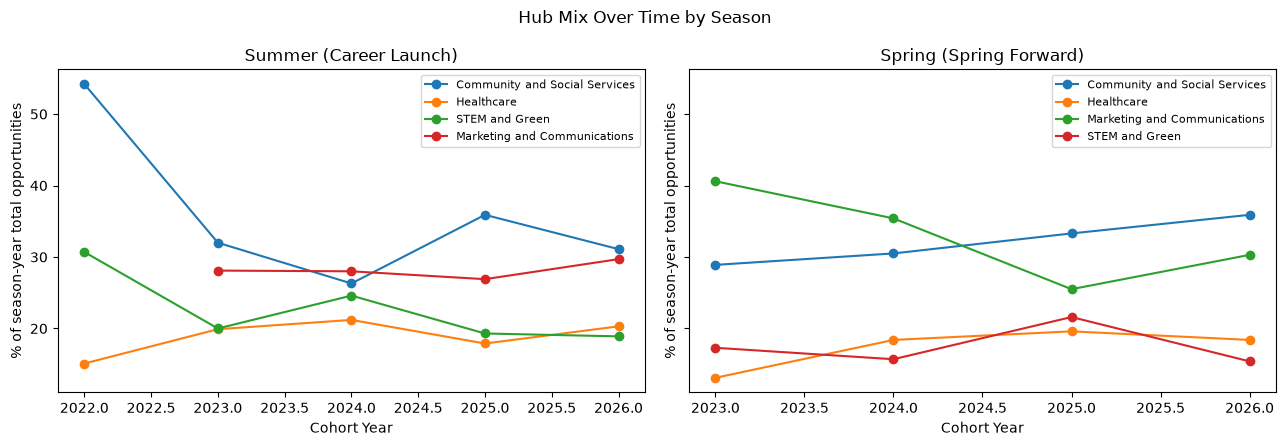


Top 8 NAICS industries by year and season (% of season-year total)
NAICS Title                          Advertising, Public Relations, and Related Services  Colleges, Universities, and Professional Schools  Computer Systems Design and Related Services  General Medical and Surgical Hospitals  Individual and Family Services  Internet Publishing and Broadcasting and Web Search Portals  Management, Scientific, and Technical Consulting Services  Outpatient Care Centers
Cohort Year Internship Season                                                                                                                                                                                                                                                                                                                                                                                    
2022        Summer (Career Launch)                                                   0.7                                        

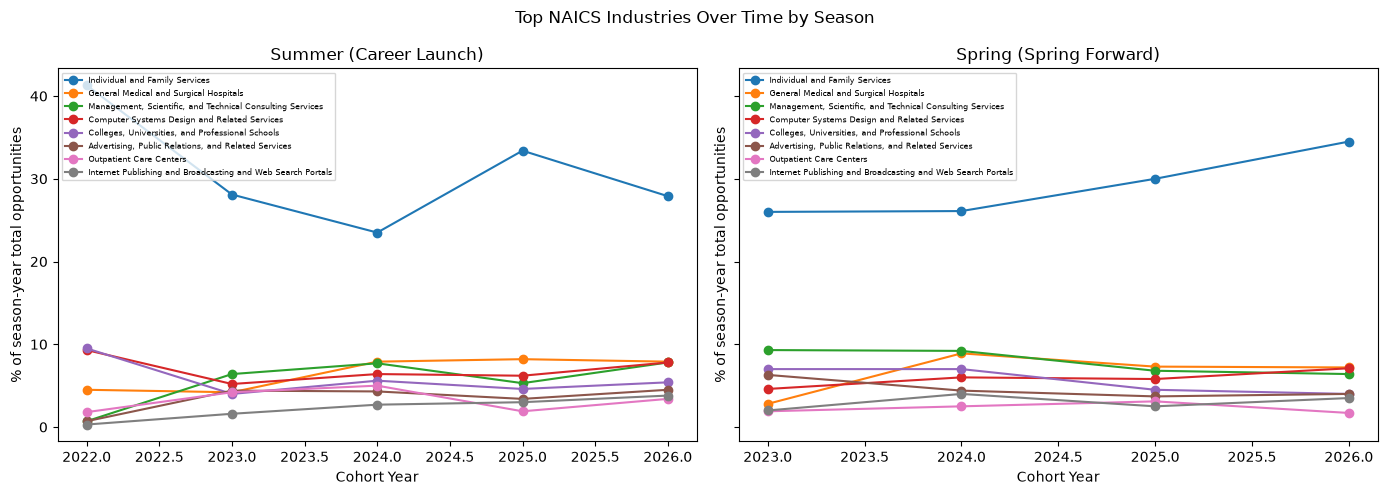


Top 8 SOC occupations by year and season (% of season-year total)
SOC Title                            Community Health Workers  Insufficient Information  Market Research Analysts and Marketing Specialists  Marketing Managers  Office and Administrative Support Workers, All Other  Receptionists and Information Clerks  Social and Human Service Assistants  Web and Digital Interface Designers
Cohort Year Internship Season                                                                                                                                                                                                                                                                                                        
2022        Summer (Career Launch)                        3.8                       9.8                                                 3.2                 2.0                                                   2.3                                   3.0                              

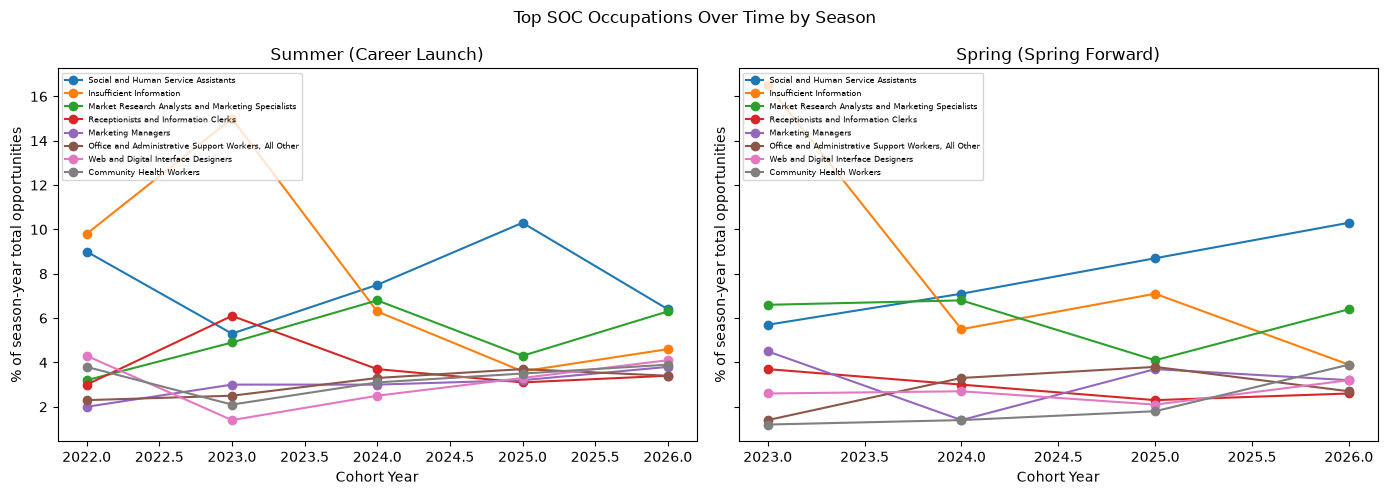



Tidy CSVs written for Power BI / further reporting:
  ../../data/timeseries_hub_by_year_season.csv
  ../../data/timeseries_naics_by_year_season.csv  (all NAICS titles, not just top 8)
  ../../data/timeseries_soc_by_year_season.csv    (all SOC titles, not just top 8)

Each has one row per (Cohort Year, Internship Season, Category) with both the raw
Count and Percent Of Season-Year Total - a Power BI line/area chart can use these
directly with Cohort Year on the x-axis, Internship Season as a slicer/legend split,
and Percent Of Season-Year Total as the value, without any further transformation.


In [4]:
# --- Time-series view: how hub / industry / occupation mix changes across
#     cohort years and internship seasons, standardized to % of total ---
#
# "Season" here is really Program Family: Career Launch = Summer cohort,
# Spring Forward = Spring cohort. Standardizing to % of that season-year's
# total opportunities matters because raw volume grew a lot 2022 -> 2026
# (we saw this in the earlier hub-by-year pivot) - looking at raw counts
# over time would just show "everything grew," which isn't the interesting
# question. % of total shows whether the MIX shifted, independent of
# overall growth.

import pandas as pd
import matplotlib.pyplot as plt

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
CODED_PATH = "../../data/AllRoles_nioccs_coded.csv"

SEASON_MAP = {"Career Launch": "Summer (Career Launch)", "Spring Forward": "Spring (Spring Forward)"}

ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")

# The coded file doesn't carry Cohort Year / Program Family (only what the
# API needed), so bring those back in via the ready file.
merged = coded.merge(
    ready[["Opportunity Identifier", "Cohort Year", "Program Family"]],
    on="Opportunity Identifier",
    how="left",
)

n_unmatched = merged["Cohort Year"].isna().sum()
if n_unmatched:
    print(f"NOTE: {n_unmatched} coded rows didn't match anything in the ready file "
          f"and have no Cohort Year/Season - excluded from the time series below.")

merged = merged.dropna(subset=["Cohort Year", "Program Family"])
merged = merged[merged["API Call Error"].isna()]  # only successfully coded rows
merged["Internship Season"] = merged["Program Family"].map(SEASON_MAP)
merged["Cohort Year"] = merged["Cohort Year"].astype(int)

print(f"Rows going into the time series: {len(merged)}\n")


def pct_of_group_total(df, group_cols, value_col):
    """Returns counts AND % of each (Cohort Year, Internship Season) group's total."""
    counts = df.groupby(group_cols + [value_col]).size().rename("Count").reset_index()
    group_totals = counts.groupby(group_cols)["Count"].transform("sum")
    counts["Percent Of Season-Year Total"] = (counts["Count"] / group_totals * 100).round(1)
    return counts


# ------------------------------------------------------------------
# 1. Hub mix over time, by season
# ------------------------------------------------------------------
hub_trend = pct_of_group_total(merged, ["Cohort Year", "Internship Season"], "Program Hub Category")
hub_trend.to_csv("../../data/timeseries_hub_by_year_season.csv", index=False)

print("=" * 70)
print("Hub mix by year and season (% of that season-year's total opportunities)")
print("=" * 70)
hub_pivot = hub_trend.pivot_table(
    index=["Cohort Year", "Internship Season"], columns="Program Hub Category",
    values="Percent Of Season-Year Total", fill_value=0
)
print(hub_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, season in zip(axes, SEASON_MAP.values()):
    sub = hub_trend[hub_trend["Internship Season"] == season]
    for hub in sub["Program Hub Category"].unique():
        s = sub[sub["Program Hub Category"] == hub].sort_values("Cohort Year")
        ax.plot(s["Cohort Year"], s["Percent Of Season-Year Total"], marker="o", label=hub)
    ax.set_title(season)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of season-year total opportunities")
    ax.legend(fontsize=8)
plt.suptitle("Hub Mix Over Time by Season")
plt.tight_layout()
plt.savefig("../../data/timeseries_hub_by_year_season.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 2. Industry (NAICS) mix over time, by season - top 8 NAICS titles overall
# ------------------------------------------------------------------
top_naics_titles = merged["NAICS Title"].value_counts().head(8).index.tolist()
naics_trend_all = pct_of_group_total(merged, ["Cohort Year", "Internship Season"], "NAICS Title")
naics_trend = naics_trend_all[naics_trend_all["NAICS Title"].isin(top_naics_titles)]
naics_trend_all.to_csv("../../data/timeseries_naics_by_year_season.csv", index=False)

print("\n" + "=" * 70)
print("Top 8 NAICS industries by year and season (% of season-year total)")
print("=" * 70)
naics_pivot = naics_trend.pivot_table(
    index=["Cohort Year", "Internship Season"], columns="NAICS Title",
    values="Percent Of Season-Year Total", fill_value=0
)
print(naics_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, season in zip(axes, SEASON_MAP.values()):
    sub = naics_trend[naics_trend["Internship Season"] == season]
    for title in top_naics_titles:
        s = sub[sub["NAICS Title"] == title].sort_values("Cohort Year")
        ax.plot(s["Cohort Year"], s["Percent Of Season-Year Total"], marker="o", label=title)
    ax.set_title(season)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of season-year total opportunities")
    ax.legend(fontsize=6, loc="upper left")
plt.suptitle("Top NAICS Industries Over Time by Season")
plt.tight_layout()
plt.savefig("../../data/timeseries_naics_by_year_season.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 3. Occupation (SOC) mix over time, by season - top 8 SOC titles overall
# ------------------------------------------------------------------
top_soc_titles = merged["SOC Title"].value_counts().head(8).index.tolist()
soc_trend_all = pct_of_group_total(merged, ["Cohort Year", "Internship Season"], "SOC Title")
soc_trend = soc_trend_all[soc_trend_all["SOC Title"].isin(top_soc_titles)]
soc_trend_all.to_csv("../../data/timeseries_soc_by_year_season.csv", index=False)

print("\n" + "=" * 70)
print("Top 8 SOC occupations by year and season (% of season-year total)")
print("=" * 70)
soc_pivot = soc_trend.pivot_table(
    index=["Cohort Year", "Internship Season"], columns="SOC Title",
    values="Percent Of Season-Year Total", fill_value=0
)
print(soc_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, season in zip(axes, SEASON_MAP.values()):
    sub = soc_trend[soc_trend["Internship Season"] == season]
    for title in top_soc_titles:
        s = sub[sub["SOC Title"] == title].sort_values("Cohort Year")
        ax.plot(s["Cohort Year"], s["Percent Of Season-Year Total"], marker="o", label=title)
    ax.set_title(season)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of season-year total opportunities")
    ax.legend(fontsize=6, loc="upper left")
plt.suptitle("Top SOC Occupations Over Time by Season")
plt.tight_layout()
plt.savefig("../../data/timeseries_soc_by_year_season.png", dpi=150)
plt.show()

print("\n\nTidy CSVs written for Power BI / further reporting:")
print("  ../../data/timeseries_hub_by_year_season.csv")
print("  ../../data/timeseries_naics_by_year_season.csv  (all NAICS titles, not just top 8)")
print("  ../../data/timeseries_soc_by_year_season.csv    (all SOC titles, not just top 8)")
print("\nEach has one row per (Cohort Year, Internship Season, Category) with both the raw")
print("Count and Percent Of Season-Year Total - a Power BI line/area chart can use these")
print("directly with Cohort Year on the x-axis, Internship Season as a slicer/legend split,")
print("and Percent Of Season-Year Total as the value, without any further transformation.")